# Preprocessing with established packages — Python

In the main notebook `rock_raman_tutorial.ipynb` the ALS, Savitzky–Golay and SNV
routines are hand-written, so that you can see what each step computes. In practice
you would reach for a package:

| Step | Package | Function |
|---|---|---|
| Baseline | [`pybaselines`](https://pybaselines.readthedocs.io/) | `whittaker.asls`, `whittaker.arpls`, `polynomial.imodpoly` … 50-plus methods |
| Smoothing / derivative | `scipy.signal` | `savgol_filter` |
| SNV | none needed | two lines of numpy |

This notebook runs the hand-written and the package versions side by side, compares
them item by item, and marks the **three defaults that will bite you** — the same three
traps appear in R's `baseline` / `prospectr` (see `r/preprocess_packages_en.R`).

```bash
pip install pybaselines numpy scipy pandas matplotlib
```

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.sparse import diags, csc_matrix
from scipy.sparse.linalg import spsolve

import pybaselines
from pybaselines.whittaker import asls, arpls
from pybaselines.polynomial import imodpoly

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.unicode_minus": False})
print("pybaselines", pybaselines.__version__)

pybaselines 1.2.1


In [2]:
d   = pd.read_csv("../data/rock_raman_2class_raw.csv")
wn  = np.array([float(c) for c in d.columns[2:]])
X   = d.iloc[:, 2:].to_numpy(float)
ids = d.iloc[:, 0].tolist()
STEP = float(np.diff(wn).mean())
print(f"X = {X.shape},  wn {wn[0]:.1f}-{wn[-1]:.1f},  mean step {STEP:.4f} cm-1")

X = (10, 664),  wn 150.0-1798.5,  mean step 2.4863 cm-1


## 1. The hand-written versions (copied from the main notebook, as the reference)

In [3]:
def D2(m):
    e = np.ones(m)
    return diags([e[:-2], -2*e[:-1], e], [0, 1, 2], shape=(m-2, m)).tocsc()

def als_hand(y, lam=1e4, p=0.01, niter=15):
    # The tutorial's hand-written ALS: always runs the full niter; a point sitting
    # exactly on the baseline counts as 'below'.
    m = len(y); DD = lam * (D2(m).T @ D2(m)); w = np.ones(m)
    for _ in range(niter):
        z = spsolve(csc_matrix(diags(w)) + DD, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

def sg_hand(y, w=9, poly=3, deriv=0):
    # Hand-written SG: pads by replicating the end points, so length is preserved.
    hw = (w - 1) // 2; k = np.arange(-hw, hw + 1)
    A = np.vander(k, poly + 1, increasing=True)
    C = np.linalg.solve(A.T @ A, A.T)
    cf = C[deriv] * float(np.prod(range(1, deriv + 1)) or 1)
    yp = np.r_[np.repeat(y[0], hw), y, np.repeat(y[-1], hw)]
    return np.array([cf @ yp[i:i+w] for i in range(len(y))])

def snv_hand(Y):
    return (Y - Y.mean(1, keepdims=True)) / Y.std(1, ddof=1, keepdims=True)

## 2. Baseline: `pybaselines.whittaker.asls`

`asls` is the Eilers & Boelens AsLS — the same algorithm as the hand-written one.
Parameter mapping:

| hand-written | `asls` | note |
|---|---|---|
| `lam=1e4` | `lam=1e4` | **also linear**, not log10 |
| `p=0.01` | `p=0.01` | same |
| `niter=15` | `max_iter=15, tol=0` | the hand-written one has no convergence test, so `tol` must be 0 to actually run all 15 |

With the parameters aligned, the two should agree to floating-point precision.

In [4]:
mx = 0.0
for y in X:
    zh = als_hand(y, 1e4, 0.01, 15)
    zp, _ = asls(y, lam=1e4, p=0.01, max_iter=15, tol=0)
    mx = max(mx, np.abs(zh - zp).max())

rng = X[0].max() - X[0].min()
print(f"max |hand - pybaselines|  over all 10 spectra : {mx:.3e}")
print(f"signal range of spectrum 1                    : {rng:.1f} counts")
print(f"relative                                      : {mx/rng:.2e}")
print("\n-> Same algorithm, aligned parameters, same numbers.")

max |hand - pybaselines|  over all 10 spectra : 7.015e-09
signal range of spectrum 1                    : 271.0 counts
relative                                      : 2.59e-11

-> Same algorithm, aligned parameters, same numbers.


### Trap #1: the default `lam` is `1e6`, not the `1e4` you hand-wrote

And — this is the one that really catches people — **`lambda` in R's
`baseline::baseline.als` is log10**: `lambda = 6` means 10⁶. The three conventions:

| | argument | default | meaning |
|---|---|---|---|
| hand-written | `lam` | 1e4 | linear |
| `pybaselines.asls` | `lam` | **1e6** | linear |
| `baseline::baseline.als` | `lambda` | **6** | **log10 → 10⁶** |

Paste the hand-written `1e4` into R's `lambda` and you have asked for 10¹⁰⁰⁰⁰.

In [5]:
def als_R(y, lambda_log10=6, p=0.05, maxit=20):
    # Replication of baseline::baseline.als (from the CRAN source). lambda is a power of ten.
    m = len(y); DD = (10.0**lambda_log10) * (D2(m).T @ D2(m)); w = np.ones(m)
    for _ in range(maxit):
        z = spsolve(csc_matrix(diags(w)) + DD, w * y)
        w_old = w; w = p * (y > z) + (1 - p) * (y < z)
        if np.sum(w_old != w) == 0: break
    return z

y = X[0]
zh    = als_hand(y)
zdef, _ = asls(y)                  # pybaselines defaults: lam=1e6, p=0.01, max_iter=50, tol=1e-3
zR6   = als_R(y, 6, 0.05, 20)      # baseline::als defaults
zR4   = als_R(y, 4, 0.01, 20)      # lambda=4 -> 1e4, aligned with hand-written

rmsd = lambda a, b: float(np.sqrt(np.mean((a-b)**2)))
print(f"hand(1e4) vs pybaselines default lam=1e6     : RMSD {rmsd(zh, zdef):7.2f} counts")
print(f"hand(1e4) vs baseline::als lambda=6, p=.05   : RMSD {rmsd(zh, zR6):7.2f} counts")
print(f"hand(1e4) vs baseline::als lambda=4, p=.01   : RMSD {rmsd(zh, zR4):7.2f} counts   <- aligned")

def peak(z, c=1008, tol=8):
    j = (wn > c-tol) & (wn < c+tol); return (y - z)[j].max()
print("\n1008 cm-1 peak height:")
for nm, z in [("hand lam=1e4", zh), ("pybaselines default lam=1e6", zdef),
              ("baseline::als lambda=6 p=.05", zR6), ("baseline::als lambda=4 p=.01", zR4)]:
    print(f"  {nm:32s} {peak(z):8.1f}")
print(f"\n-> The defaults differ by {100*(peak(zh)-peak(zR6))/peak(zh):.1f}%. If you use peak height for")
print("   semi-quantitative work, that is not a rounding error.")

hand(1e4) vs pybaselines default lam=1e6     : RMSD    3.90 counts
hand(1e4) vs baseline::als lambda=6, p=.05   : RMSD    6.64 counts
hand(1e4) vs baseline::als lambda=4, p=.01   : RMSD    0.00 counts   <- aligned

1008 cm-1 peak height:
  hand lam=1e4                        143.1
  pybaselines default lam=1e6         141.5
  baseline::als lambda=6 p=.05        134.5
  baseline::als lambda=4 p=.01        143.1

-> The defaults differ by 6.0%. If you use peak height for
   semi-quantitative work, that is not a rounding error.


### Other `pybaselines` methods worth trying

AsLS is one of fifty-odd. For Raman fluorescence backgrounds the other common choices
are **arPLS** (weights adapt automatically, no `p` to guess) and **imodPoly** (iterative
polynomial, robust against slowly curving backgrounds).

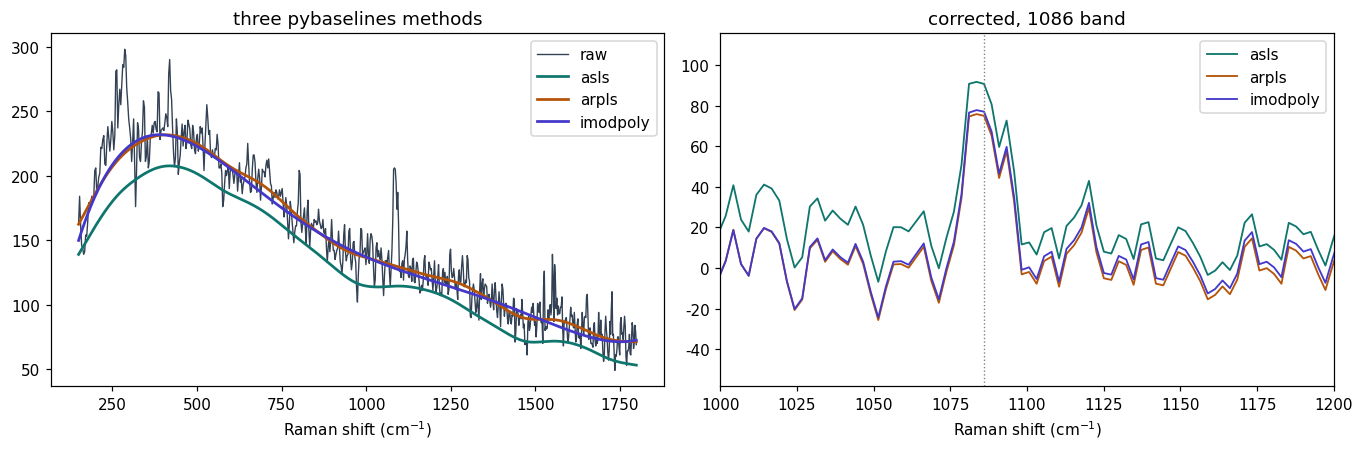

asls       1086 peak height =    91.7
arpls      1086 peak height =    75.8
imodpoly   1086 peak height =    77.7


In [6]:
y = X[ids.index("marble4")] if "marble4" in ids else X[8]
b_asls,  _ = asls(y, lam=1e4, p=0.01)
b_arpls, _ = arpls(y, lam=1e5)
b_imod,  _ = imodpoly(y, x_data=wn, poly_order=5)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax[0].plot(wn, y, color="#334155", lw=.9, label="raw")
for nm, b, c in [("asls", b_asls, "#0F766E"), ("arpls", b_arpls, "#B45309"),
                 ("imodpoly", b_imod, "#4338CA")]:
    ax[0].plot(wn, b, lw=1.8, label=nm, color=c)
ax[0].legend(); ax[0].set_title("three pybaselines methods"); ax[0].set_xlabel("Raman shift (cm$^{-1}$)")
for nm, b, c in [("asls", b_asls, "#0F766E"), ("arpls", b_arpls, "#B45309"),
                 ("imodpoly", b_imod, "#4338CA")]:
    ax[1].plot(wn, y - b, lw=1.2, label=nm, color=c)
ax[1].set_xlim(1000, 1200); ax[1].axvline(1086, color="grey", ls=":", lw=.9)
ax[1].legend(); ax[1].set_title("corrected, 1086 band"); ax[1].set_xlabel("Raman shift (cm$^{-1}$)")
plt.tight_layout(); plt.show()

for nm, b in [("asls", b_asls), ("arpls", b_arpls), ("imodpoly", b_imod)]:
    j = (wn > 1078) & (wn < 1094)
    print(f"{nm:10s} 1086 peak height = {(y-b)[j].max():7.1f}")

## 3. Smoothing: `scipy.signal.savgol_filter`

The interior coefficients are identical in all three; **the difference is entirely at the edges**:

| | edge handling | output length |
|---|---|---|
| hand-written | replicate the end points | 664 (unchanged) |
| `savgol_filter` (default `mode='interp'`) | polynomial extrapolation at the ends | 664 (unchanged) |
| `prospectr::savitzkyGolay` | **discarded** | 656 (w−1 fewer) |

In [7]:
def sg_prospectr(y, w=9, poly=3, m=0, delta=None):
    # Replication of prospectr::savitzkyGolay: valid convolution, (w-1)/2 dropped each end.
    hw = (w - 1) // 2; k = np.arange(-hw, hw + 1)
    A = np.vander(k, poly + 1, increasing=True)
    C = np.linalg.solve(A.T @ A, A.T)
    cf = C[m] * float(np.prod(range(1, m + 1)) or 1)
    o = np.convolve(y, cf[::-1], mode="valid")
    return o / delta**m if (delta and m) else o

y = X[0]; g = 4
h  = sg_hand(y)
s  = savgol_filter(y, 9, 3)
pr = sg_prospectr(y)

print(f"length     hand {len(h)}   scipy {len(s)}   prospectr {len(pr)}   (input {len(y)})")
print(f"interior   hand vs scipy      max diff {np.abs(h[g:-g]-s[g:-g]).max():.3e}")
print(f"interior   hand vs prospectr  max diff {np.abs(h[g:-g]-pr).max():.3e}")
print(f"interior   scipy vs prospectr max diff {np.abs(s[g:-g]-pr).max():.3e}")
print(f"\nedge       point 1  hand {h[0]:8.2f}   scipy {s[0]:8.2f}   diff {abs(h[0]-s[0]):.2f}")
print(f"           point 2  hand {h[1]:8.2f}   scipy {s[1]:8.2f}   diff {abs(h[1]-s[1]):.2f}")
print("\n-> Interior agrees to 1e-13; the edges differ by several counts. Usually")
print("   irrelevant for band assignment -- unless a diagnostic band sits near an end.")

length     hand 664   scipy 664   prospectr 656   (input 664)
interior   hand vs scipy      max diff 3.411e-13
interior   hand vs prospectr  max diff 5.684e-14
interior   scipy vs prospectr max diff 3.411e-13

edge       point 1  hand   134.70   scipy   141.51   diff 6.80
           point 2  hand   128.90   scipy   130.44   diff 1.54

-> Interior agrees to 1e-13; the edges differ by several counts. Usually
   irrelevant for band assignment -- unless a diagnostic band sits near an end.


### Trap #2: switch to `prospectr` and the wavenumber axis must be trimmed too

`savgol_filter` preserves length, so Python makes this harder to trip over. But the
moment you use `prospectr` in R, or convolve with `mode='valid'` yourself, `X` has 8
fewer columns while `wn` still has 664 — and the whole VIP table shifts by **4 points**,
which on this data is **12.0 cm⁻¹**. Enough to read 1008 as 1020.

In [8]:
wn_sg = wn[g:-g]
print(f"wn {len(wn)} -> wn_sg {len(wn_sg)}   ({wn[0]:.1f}-{wn[-1]:.1f} -> {wn_sg[0]:.1f}-{wn_sg[-1]:.1f})")
print(f"Forget to trim and column i gets labelled wn[i] instead of wn_sg[i]: shift = {wn[g]-wn[0]:.1f} cm-1")

wn 664 -> wn_sg 656   (150.0-1798.5 -> 162.0-1790.3)
Forget to trim and column i gets labelled wn[i] instead of wn_sg[i]: shift = 12.0 cm-1


### Trap #3: the units of a derivative

`savgol_filter(..., deriv=1)` defaults to `delta=1.0`, so the result is change **per data
point**. To get "per cm⁻¹" you must pass `delta`. The `prospectr` argument is `delta.wav`.

Classification is unaffected (it is a global constant), but the moment you **quote a
number**, or compare against someone else's data, you have to pass it.

In [9]:
d_idx = savgol_filter(y, 9, 3, deriv=1)                # delta = 1
d_wav = savgol_filter(y, 9, 3, deriv=1, delta=STEP)    # delta = 2.4863
print(f"delta=1      max|d1| = {np.abs(d_idx).max():.4f}   (per point)")
print(f"delta={STEP:.4f} max|d1| = {np.abs(d_wav).max():.4f}   (per cm-1)")
print(f"ratio = {np.abs(d_idx).max()/np.abs(d_wav).max():.4f}   = mean step")

pr1 = sg_prospectr(y, m=1, delta=STEP)
print(f"\nprospectr(delta.wav) vs scipy(delta), interior: max diff = {np.abs(pr1 - d_wav[g:-g]).max():.3e}")
print("-> The two definitions agree.")

delta=1      max|d1| = 49.9192   (per point)
delta=2.4863 max|d1| = 20.0773   (per cm-1)
ratio = 2.4863   = mean step

prospectr(delta.wav) vs scipy(delta), interior: max diff = 1.066e-14
-> The two definitions agree.


## 4. SNV: no trap here

`prospectr::standardNormalVariate` divides by **n−1** (like R's `sd()` and numpy's
`ddof=1`). A hand-written `Y.std(1)` — numpy's default `ddof=0` — differs slightly.

In [10]:
A = snv_hand(X)                                            # ddof=1
B = (X - X.mean(1, keepdims=True))
B = B / np.sqrt((B**2).sum(1, keepdims=True) / (X.shape[1] - 1))   # what prospectr does
C = (X - X.mean(1, keepdims=True)) / X.std(1, ddof=0, keepdims=True)  # numpy default

print(f"hand(ddof=1) vs prospectr : max diff {np.abs(A-B).max():.3e}   <- exactly equal")
print(f"hand(ddof=1) vs ddof=0    : max diff {np.abs(A-C).max():.3e}")
print(f"                            ratio sqrt(n/(n-1)) = {np.sqrt(X.shape[1]/(X.shape[1]-1)):.6f}")
print("\n-> 0.075% over 664 points: irrelevant for classification. Pick out 20")
print("   wavenumbers instead and it starts to matter.")

hand(ddof=1) vs prospectr : max diff 0.000e+00   <- exactly equal
hand(ddof=1) vs ddof=0    : max diff 5.559e-03
                            ratio sqrt(n/(n-1)) = 1.000754

-> 0.075% over 664 points: irrelevant for classification. Pick out 20
   wavenumbers instead and it starts to matter.


## 5. Hand-written or package?

**Use the package.** The hand-written code in this tutorial exists so you can see the
algorithm. For real analysis, use the package:

1. **Reproducibility.** `asls(y, lam=1e4, p=0.01)` documents the method in one line;
   your hand-written function has to be read line by line by anyone checking it.
2. **Edge cases are handled.** NaNs, all-zero spectra, ill-conditioned matrices — a few
   thousand people have already hit those.
3. **Choice.** `pybaselines` ships fifty-odd baseline algorithms; switching is a function name.

But — **state the version and the parameters in your methods section**:

> Baselines were removed with the AsLS algorithm (`pybaselines` 1.2.1,
> `whittaker.asls`, `lam` = 1×10⁴, `p` = 0.01, 15 iterations); spectra were then
> smoothed with a Savitzky–Golay filter (`scipy.signal.savgol_filter`,
> window 9, polynomial order 3) and normalised with SNV.

"ALS baseline correction was applied" says nothing usable — the single parameter `lam`
follows two different conventions across three common implementations.

## 6. See also

- R version: `r/preprocess_packages_en.R` (`baseline` + `prospectr`, same item-by-item comparison)
- Hand-written versions and the full analysis: `rock_raman_tutorial_en.ipynb`
- The tutorial itself: `index_en.html`, Part 7